In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from evaluation_function import evaluate_strategy_full, plot_strategy_vs_buy_hold, prepare_post_trade_df

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

In [2]:
eth_macd=pd.read_csv('../datasets/eth_macd_18_50_13_post_trade_table.csv',parse_dates=True,index_col=0)
btc_macd=pd.read_csv('../datasets/btc_macd_16_20_15_post_trade_table.csv',parse_dates=True,index_col=0)

eth_macd.rename(columns={
    'trade': 'macd_trade',
    'position': 'macd_position',
    'trade_action': 'macd_trade_action'
}, inplace=True)

btc_macd.rename(columns={
    'trade': 'macd_trade',
    'position': 'macd_position',
    'trade_action': 'macd_trade_action'
}, inplace=True)


In [3]:
eth_bollinger=pd.read_csv('../datasets/eth_bollinger_post_trade_table.csv',parse_dates=True,index_col=0)
btc_bollinger=pd.read_csv('../datasets/btc_bollinger_post_trade_table.csv',parse_dates=True,index_col=0)

eth_bollinger.rename(columns={
    'trade': 'bollinger_trade',
    'position': 'bollinger_position',
    'trade_action': 'bollinger_trade_action'
}, inplace=True)

btc_bollinger.rename(columns={
    'trade': 'bollinger_trade',
    'position': 'bollinger_position',
    'trade_action': 'bollinger_trade_action'
}, inplace=True)


In [4]:
# Ensure both indices are datetime
eth_bollinger.index = pd.to_datetime(eth_bollinger.index, format='mixed', dayfirst=True)
btc_bollinger.index = pd.to_datetime(btc_bollinger.index, format='mixed', dayfirst=True)
eth_macd.index = pd.to_datetime(eth_macd.index)
btc_macd.index = pd.to_datetime(btc_macd.index)

# sort index just to be safe
eth_bollinger = eth_bollinger.sort_index()
eth_macd = eth_macd.sort_index()

btc_bollinger = btc_bollinger.sort_index()
btc_macd = btc_macd.sort_index()

# Join (ETH with ETH, BTC with BTC)
eth_combined = eth_bollinger.join(
    eth_macd.drop(columns=['price', 'log_return']),
    how='inner'
)

btc_combined = btc_bollinger.join(
    btc_macd.drop(columns=['price', 'log_return']),
    how='inner'
)



In [5]:
btc_combined = btc_combined.reset_index()
eth_combined = eth_combined.reset_index()

print(eth_combined.duplicated(subset=['date']).sum())
print(btc_combined.duplicated(subset=['date']).sum())

0
0


### Section 2: Trend Strength & Regime Switching

In [6]:

# --- Sweep parameters ---
L_values         = [30, 45, 60, 90]
threshold_values = [0.20, 0.35, 0.50]

sweep_results = []

for asset_name, df_raw in [("ETH", eth_combined.copy()), ("BTC", btc_combined.copy())]:
    for L, threshold in itertools.product(L_values, threshold_values):

        df = df_raw.copy()

        df["trend_strength"] = (
            (df["price"] - df["price"].shift(L))
            / df["price"].diff().abs().rolling(L).sum()
        )

        df["position"] = np.where(
            df["trend_strength"].abs().fillna(0) > threshold,
            df["macd_position"],
            df["bollinger_position"],
        )
        df["position"] = df["position"].ffill().fillna(0)
        df["trade"] = df["position"].diff().fillna(0).clip(-1, 1)

        try:
            _, _, summary = evaluate_strategy_full(
                df,
                price_col="price",
                position_col="position",
                trade_col="trade",
                log_return_col="log_return",
            )
            sweep_results.append({
                "asset":          asset_name,
                "L":              L,
                "threshold":      threshold,
                "sharpe":         round(summary["sharpe_ratio_rf_3pct"], 4),
                "ann_return":     round(summary["annualised_return"],    4),
                "max_drawdown":   round(summary["max_drawdown"],         4),
                "ann_volatility": round(summary["annualised_volatility"],4),
                "cumulative_pnl": round(summary["cumulative_pnl"],       4),
                "n_trades":       summary["number_of_complete_trades"],
                "win_rate":       round(summary["win_rate"], 4) if not np.isnan(summary["win_rate"]) else np.nan,
                "exposure_rate":  round(summary["exposure_rate"],        4),
            })
        except Exception as e:
            sweep_results.append({"asset": asset_name, "L": L, "threshold": threshold, "error": str(e)})

sweep_df = pd.DataFrame(sweep_results)

print("=== Top 10 combinations by Sharpe ===")
print(
    sweep_df
    .dropna(subset=["sharpe"])
    .sort_values("sharpe", ascending=False)
    .head(10)
    .to_string(index=False)
)

=== Top 10 combinations by Sharpe ===
asset  L  threshold  sharpe  ann_return  max_drawdown  ann_volatility  cumulative_pnl  n_trades  win_rate  exposure_rate
  ETH 30       0.20  1.1552      0.7372       -0.6989          0.6167         82.0616       225    0.6667         0.4848
  BTC 30       0.20  0.5452      0.1872       -0.6572          0.4299          2.9475       242    0.5289         0.4605
  ETH 45       0.20 -0.1147     -0.2333       -0.9130          0.6545         -0.8807       208    0.4663         0.5043
  BTC 45       0.20 -0.1371     -0.1265       -0.8398          0.4532         -0.6611       197    0.4213         0.5022
  ETH 30       0.35 -0.4050     -0.3693       -0.9765          0.6588         -0.9750       218    0.4862         0.5231
  BTC 30       0.35 -0.4248     -0.2381       -0.9374          0.4598         -0.8866       201    0.4677         0.4954
  BTC 60       0.20 -0.6108     -0.3177       -0.9547          0.4830         -0.9531       182    0.4066         0

### Section 3 : Evaluation 

In [7]:
# Pick best combo per asset from sweep and rebuild for plotting
best_btc = sweep_df[sweep_df["asset"] == "BTC"].sort_values("sharpe", ascending=False).iloc[0]
best_eth = sweep_df[sweep_df["asset"] == "ETH"].sort_values("sharpe", ascending=False).iloc[0]

for df_combined, best in [(btc_combined, best_btc), (eth_combined, best_eth)]:
    L, threshold = int(best["L"]), best["threshold"]
    df_combined["trend_strength"] = (
        (df_combined["price"] - df_combined["price"].shift(L))
        / df_combined["price"].diff().abs().rolling(L).sum()
    )
    df_combined["position"] = np.where(
        df_combined["trend_strength"].abs().fillna(0) > threshold,
        df_combined["macd_position"],
        df_combined["bollinger_position"],
    )
    df_combined["position"] = df_combined["position"].ffill().fillna(0)
    df_combined["trade"] = df_combined["position"].diff().fillna(0).clip(-1, 1)

In [8]:
btc_post = prepare_post_trade_df(btc_combined)
eth_post = prepare_post_trade_df(eth_combined)

In [9]:
btc_daily_eval, btc_trade_log, btc_summary = evaluate_strategy_full(
    btc_post,
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
)

In [10]:
eth_daily_eval, eth_trade_log, eth_summary = evaluate_strategy_full(
    eth_post,
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
)


--- Final Strategy Performance ---
cumulative_pnl: 2.9475
average_daily_pnl: 0.0007
max_drawdown: -0.6572
annualised_return: 0.1872
sharpe_ratio_rf_3pct: 0.5452
daily_std_dev: 0.0225
annualised_volatility: 0.4299
exposure_rate: 0.4605
total_turnover: 394.0000
number_of_trades_total: 242.0000
number_of_complete_trades: 242.0000
win_rate: 0.5289
average_trade_return: 0.0097
median_trade_return: 0.0041
average_win_return: 0.0607
average_loss_return: -0.0477
profit_factor: 1.4300
payoff_ratio: 1.2736
expectancy_per_trade: 0.0097
best_trade: 0.5864
worst_trade: -0.2071
average_holding_periods: 5.5579
median_holding_periods: 3.0000
long_trades: 165.0000
short_trades: 77.0000


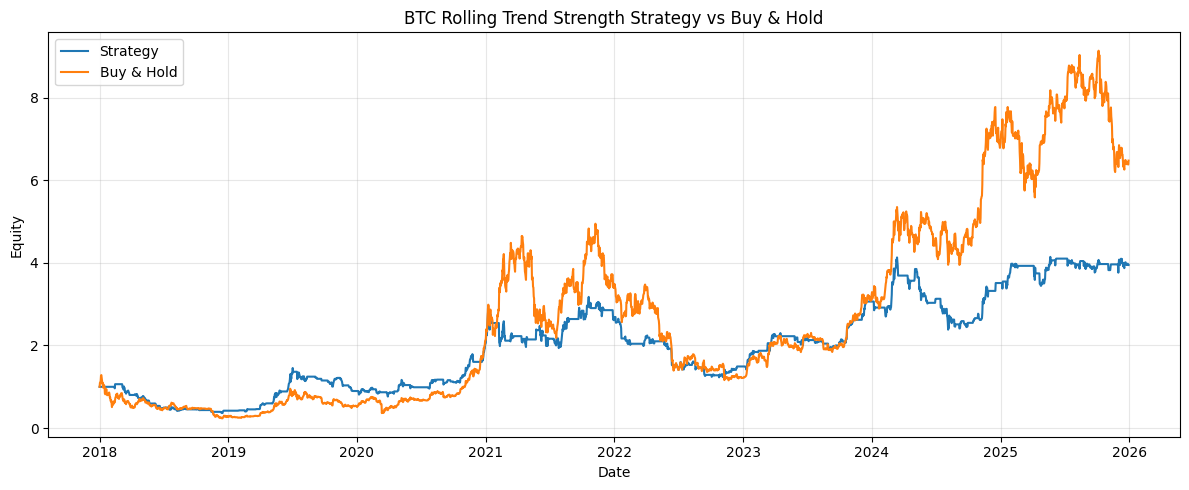

In [11]:
## BTC
print("\n--- Final Strategy Performance ---")
for k, v in btc_summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(
    btc_daily_eval,
    title="BTC Rolling Trend Strength Strategy vs Buy & Hold"
)   


--- Final Strategy Performance ---
cumulative_pnl: 82.0616
average_daily_pnl: 0.0020
max_drawdown: -0.6989
annualised_return: 0.7372
sharpe_ratio_rf_3pct: 1.1552
daily_std_dev: 0.0323
annualised_volatility: 0.6167
exposure_rate: 0.4848
total_turnover: 371.0000
number_of_trades_total: 225.0000
number_of_complete_trades: 225.0000
win_rate: 0.6667
average_trade_return: 0.0268
median_trade_return: 0.0145
average_win_return: 0.0790
average_loss_return: -0.0775
profit_factor: 2.0382
payoff_ratio: 1.0191
expectancy_per_trade: 0.0268
best_trade: 0.8243
worst_trade: -0.3324
average_holding_periods: 6.2933
median_holding_periods: 4.0000
long_trades: 164.0000
short_trades: 61.0000


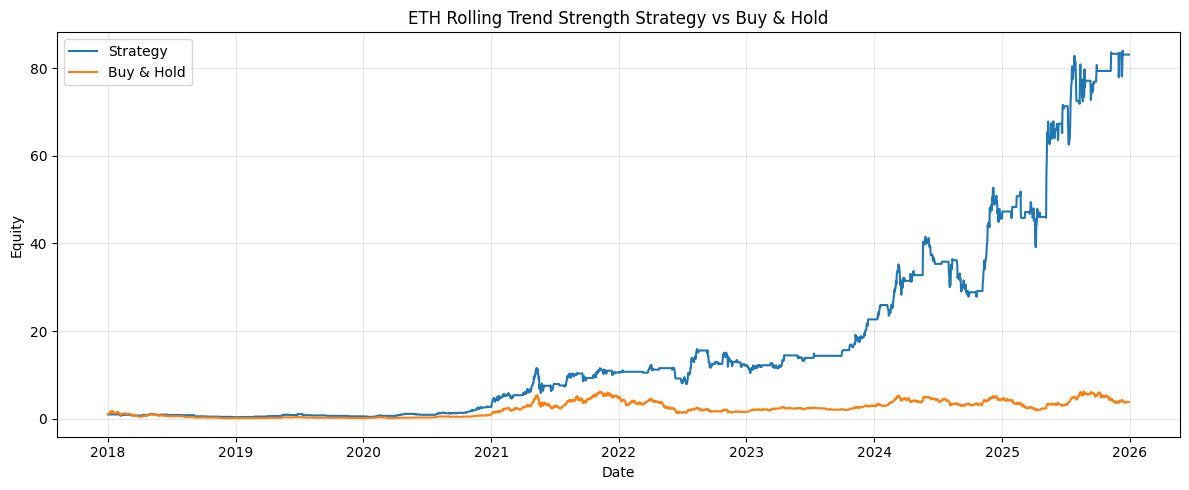

In [12]:
## ETH
print("\n--- Final Strategy Performance ---")
for k, v in eth_summary.items():
    print(f"{k}: {v:.4f}")
plot_strategy_vs_buy_hold(
    eth_daily_eval,
    title="ETH Rolling Trend Strength Strategy vs Buy & Hold"
)

In [13]:
## Save to csv
#btc_combined.to_csv("../datasets/btc_rolling_trend_strength.csv", index=False)
#eth_combined.to_csv("../datasets/eth_rolling_trend_strength.csv", index=False)